In [3]:
%pip install ollama

In [2]:
import json
import pandas as pd
import pathlib
import ollama
import sys

In [2]:
df = pd.read_sql("SELECT timestamp_ms FROM telemetry_samples ORDER BY id", "sqlite:///track1.db")
# df.to_csv("telemetry_export.csv", index=False)
print(df.describe())

       timestamp_ms
count  3.194000e+03
mean   9.262427e+07
std    6.016762e+04
min    9.250858e+07
25%    9.257589e+07
50%    9.262578e+07
75%    9.267567e+07
max    9.272556e+07


In [50]:
df = pd.read_sql(
    """
    SELECT 
        timestamp_utc AS timestamp,
        acceleration_x,
        acceleration_y,
        acceleration_z,
        yaw,
        position_x,
        position_y,
        position_z,
        speed 
    FROM telemetry_samples
    WHERE distance_traveled != 0
    ORDER BY id
    """,
    "sqlite:///track2_good.db"
)

def preprocess(df):
    df['timestamp'] = pd.to_datetime(df["timestamp"], utc=True).astype("int64") // 10**6
    df['timestamp'] = (df['timestamp'] - min(df['timestamp'])) / 1000

    df['position_x'] = df['position_x'].astype(int)
    df['position_y'] = df['position_y'].astype(int)
    df['position_z'] = df['position_z'].astype(int)

    df['acceleration_x'] = df['acceleration_x'].astype(int)
    df['acceleration_y'] = df['acceleration_y'].astype(int)
    df['acceleration_z'] = df['acceleration_z'].astype(int)
    df['yaw'] = df['yaw'].round(decimals=2)
    df['speed'] = df['speed'].astype(int)
    
    return df

df_fast = preprocess(df)

df_fast = df_fast.iloc[::19, :]
print(df_fast.shape)

(51, 9)


In [51]:
df2 = pd.read_sql(
    """
    SELECT 
        timestamp_utc AS timestamp,
        acceleration_x,
        acceleration_y,
        acceleration_z,
        yaw,
        position_x,
        position_y,
        position_z,
        speed 
    FROM telemetry_samples
    WHERE distance_traveled != 0
    ORDER BY id
    """,
    "sqlite:///track2_bad.db"
)

df_slow = preprocess(df2)

x = max(df_slow["timestamp"]) / max(df_fast["timestamp"])

df_slow = df_slow.iloc[::int(19*x), :]
print(df_slow.shape)

(51, 9)


In [52]:
print(df_slow.shape, df_fast.shape)

(51, 9) (51, 9)


In [53]:
df_combined = df_fast.copy()
for col in df_fast.columns:
    df_combined[col] = list(zip(df_fast[col], df_slow[col]))

print(df_combined)

            timestamp acceleration_x acceleration_y acceleration_z  \
0          (0.0, 0.0)         (0, 0)         (0, 0)         (0, 0)   
19      (0.98, 1.407)         (0, 0)         (0, 0)        (14, 5)   
38     (1.986, 2.828)         (0, 2)         (0, 0)        (15, 4)   
57      (2.979, 4.27)         (0, 0)         (0, 0)        (12, 6)   
76     (3.994, 5.699)         (0, 0)         (0, 0)         (1, 4)   
95     (5.002, 7.154)         (4, 0)         (0, 0)         (9, 1)   
114    (5.999, 8.618)         (3, 1)         (2, 0)         (6, 0)   
133   (7.015, 10.127)        (13, 5)         (4, 0)         (8, 0)   
152   (8.026, 11.626)        (12, 7)         (2, 0)       (-20, 0)   
171   (9.068, 13.134)        (14, 0)         (0, 0)        (-2, 0)   
190   (10.074, 14.61)        (20, 0)         (1, 0)        (9, -1)   
209  (11.071, 16.081)         (3, 0)         (0, 0)        (9, -1)   
228  (12.092, 17.557)        (19, 7)         (0, 0)       (-2, -1)   
247  (13.082, 19.072

In [54]:
df_combined

,timestamp,acceleration_x,acceleration_y,acceleration_z,yaw,position_x,position_y,position_z,speed
0,"(0.0, 0.0)","(0, 0)","(0, 0)","(0, 0)","(-2.5, -2.5)","(981, 981)","(303, 303)","(2664, 2664)","(0, 0)"
19,"(0.98, 1.407)","(0, 0)","(0, 0)","(14, 5)","(-2.5, -2.5)","(978, 980)","(303, 303)","(2660, 2663)","(11, 2)"
38,"(1.986, 2.828)","(0, 2)","(0, 0)","(15, 4)","(-2.49, -2.5)","(967, 975)","(302, 302)","(2645, 2656)","(25, 9)"
57,"(2.979, 4.27)","(0, 0)","(0, 0)","(12, 6)","(-2.48, -2.48)","(947, 962)","(300, 301)","(2619, 2640)","(39, 18)"
76,"(3.994, 5.699)","(0, 0)","(0, 0)","(1, 4)","(-2.49, -2.48)","(919, 944)","(297, 299)","(2582, 2616)","(50, 24)"
95,"(5.002, 7.154)","(4, 0)","(0, 0)","(9, 1)","(-2.39, -2.48)","(883, 921)","(294, 297)","(2540, 2586)","(59, 27)"
114,"(5.999, 8.618)","(3, 1)","(2, 0)","(6, 0)","(-2.18, -2.48)","(836, 896)","(290, 295)","(2498, 2553)","(65, 28)"
133,"(7.015, 10.127)","(13, 5)","(4, 0)","(8, 0)","(-1.85, -2.27)","(783, 866)","(286, 292)","(2467, 2521)","(59, 29)"
152,"(8.026, 11.626)","(12, 7)","(2, 0)","(-20, 0)","(-1.8, -2.07)","(727, 830)","(282, 289)","(2450, 2496)","(49, 30)"
171,"(9.068, 13.134)","(14, 0)","(0, 0)","(-2, 0)","(-1.57, -1.96)","(678, 788)","(281, 286)","(2443, 2479)","(46, 29)"


In [71]:
records = df_combined.to_dict(orient="records")
# with open("segment_data2_comparison.json", "w", encoding="utf-8") as f:
#     json.dump(records, f, ensure_ascii=False, indent=2)

# print(f"{len(df_slow)} Einträge geschrieben nach segment_data.json")
text = str(records)
for char in '[]{}()':
    text = text.replace(char, '')
    
text = text.replace('timestamp', '\ntimestamp')

with open("output.txt", "w", encoding="utf-8") as f:
    f.write(text)

In [83]:
df = pd.read_sql(
    """
    SELECT
      timestamp_utc AS timestamp,
      engine_max_rpm,
      current_engine_rpm,
      acceleration_x, acceleration_y, acceleration_z,
      velocity_x, velocity_y, velocity_z,
      yaw, pitch, roll,
      position_x, position_y, position_z,
      speed, power, torque, steer,
      best_lap, current_lap, lap_number, race_position
    FROM telemetry_samples
    WHERE lap_number = 0
    AND distance_traveled != 0
    ORDER BY id
    LIMIT 400
    """,
    "sqlite:///track2.db",
)

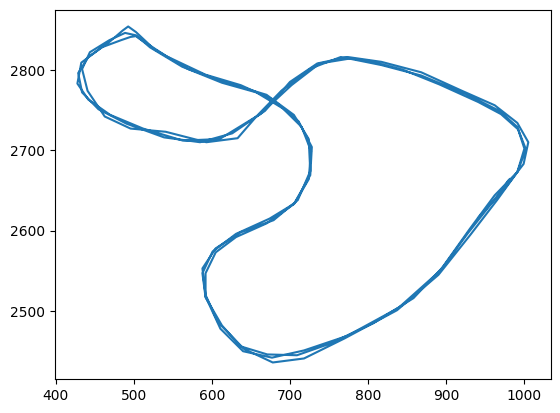

In [5]:
import matplotlib.pyplot as plt
plt.plot(df['position_x'], df['position_z'])

In [33]:
text = pathlib.Path("segment_data.json").read_text(encoding="utf-8")

resp = ollama.chat(
    model="gpt-oss:20b",
    messages=[
        {"role": "system", "content": "Du bist ein erfahrener Rennfahrer-Coach. Du analysierst Fahrdaten, gibst präzises Feedback zu Linie, Bremspunkten, Gas/Bremse-Dosierung, Lenkung und Setup. Antworte kurz, fokussiert und praxisnah."},
        {"role": "user", "content": f"Analysiere diese Session:\n```json\n{text}\n```"},
    ],
)
print(resp["message"]["content"])


In [3]:
text = pathlib.Path("segment_data2.json").read_text(encoding="utf-8")

messages = [
    # {"role": "system", "content": "Du bist ein erfahrener Rennfahrer-Coach. Du analysierst Fahrdaten und gibst präzises Feedback zu Linie, Bremspunkten, Gas/Bremse-Dosierung, Lenkung und Setup. Antworte kurz, fokussiert, praxisnah, maximal 2 Sätze. Gib dabei aber immer konkrete Timestamps, umgerechnet in Sekunden an."},
    # {"role": "user", "content": f"Analysiere diese Session:\n```json\n{text}\n```"},
    {"role": "system", "content": "Du beschreibst die Strecke, die in dem Datensatz vorhanden ist. Dein Wörterbuch dafür sind folgende Wörter : Gerade, Linkskurve, Rechtskurve"},
    {"role": "user", "content": f"Beschreibe die Strecke:\n```json\n{text}\n```"},
]

for chunk in ollama.chat(model="nemotron-3-nano:30b", messages=messages, stream=True):
    sys.stdout.write(chunk["message"]["content"])
    sys.stdout.flush()

Linkskurve